In [4]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import time
import matplotlib.ticker as ticker

from chebyshev_hofbauer_resonances.general_tent_map.approx_transfer_op import (
    approx_super_adjacency,
    create_adjacency_matricies,
    approx_ulams,
)

plt.rcParams.update({
    'font.family': 'serif',        # Matches typical LaTeX document fonts
    'font.size': 12,               # Base font size
    'axes.labelsize': 14,          # Larger axis labels
    'xtick.labelsize': 12,         # Tick sizes
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.grid': True,             # Turn on grid
    'grid.alpha': 0.4,             # Make grid faint so it doesn't distract
    'grid.linestyle': '--',        # Dashed grid lines
    'figure.dpi': 300,             # 300 DPI is standard for publication
    # 'text.usetex': True          # Uncomment if you have a full LaTeX engine installed
})

In [3]:
# function definition
alpha = 1.6
function_domains = [(0, 0.5), (0.5, 1)]
functions = [lambda x: alpha * x, lambda x: alpha * (1 - x)]
inverses = [lambda y: y / alpha, lambda y: 1 - (y / alpha)]
derivatives = [lambda _: alpha, lambda _: -alpha]

In [5]:
domains, adj_matrices = create_adjacency_matricies(
        function_domains, functions, depth=5
    )

In [7]:
adj_matrices

[array([[0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 1, 0, 1],
        [0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0]])]

In [8]:
domains

[(0, 1),
 (0.0, 0.8),
 (0.31999999999999995, 0.8),
 (0.5119999999999999, 0.8),
 (0.31999999999999995, 0.7808000000000002)]

In [4]:
# functions
def super_adj_spec(NK, depth, spec_size = 3):
    N = K = NK

    super_adjacency = approx_super_adjacency(
        function_domains,
        functions,
        inverses,
        derivatives,
        N=N,
        K=K,
        depth=depth,
    )

    evals_super_adj = np.linalg.eigvals(super_adjacency)
    evals_super_adj = evals_super_adj[np.argsort(-np.abs(evals_super_adj))]

    eval_mags = np.abs(evals_super_adj)

    spec = eval_mags[:spec_size]
    return spec, evals_super_adj



def ulam_spec(N, M, spec_size=3):
    L_ulam = approx_ulams(
        function_domains,
        functions,
        inverses,
        derivatives,
        N=N,
        M=M,
    )

    evals_ulam = np.linalg.eigvals(L_ulam)
    evals_ulam = evals_ulam[np.argsort(-np.abs(evals_ulam))]

    eval_mags = np.abs(evals_ulam)
    eval_mags = np.sort(eval_mags)[::-1]

    spec = eval_mags[:spec_size]
    return spec, evals_ulam

In [29]:
spec_mags = []
specs = []
times = []

depths = np.arange(2, 1_000)

for d in depths:
    tic = time.time()
    res = super_adj_spec(1, d, 2)
    spec_mags.append(res[0])
    specs.append(res[1])
    toc = time.time()
    times.append(toc - tic)

spec_mags = np.array(spec_mags)

KeyboardInterrupt: 

In [35]:
l2 = np.array([spec[1] for spec in specs])

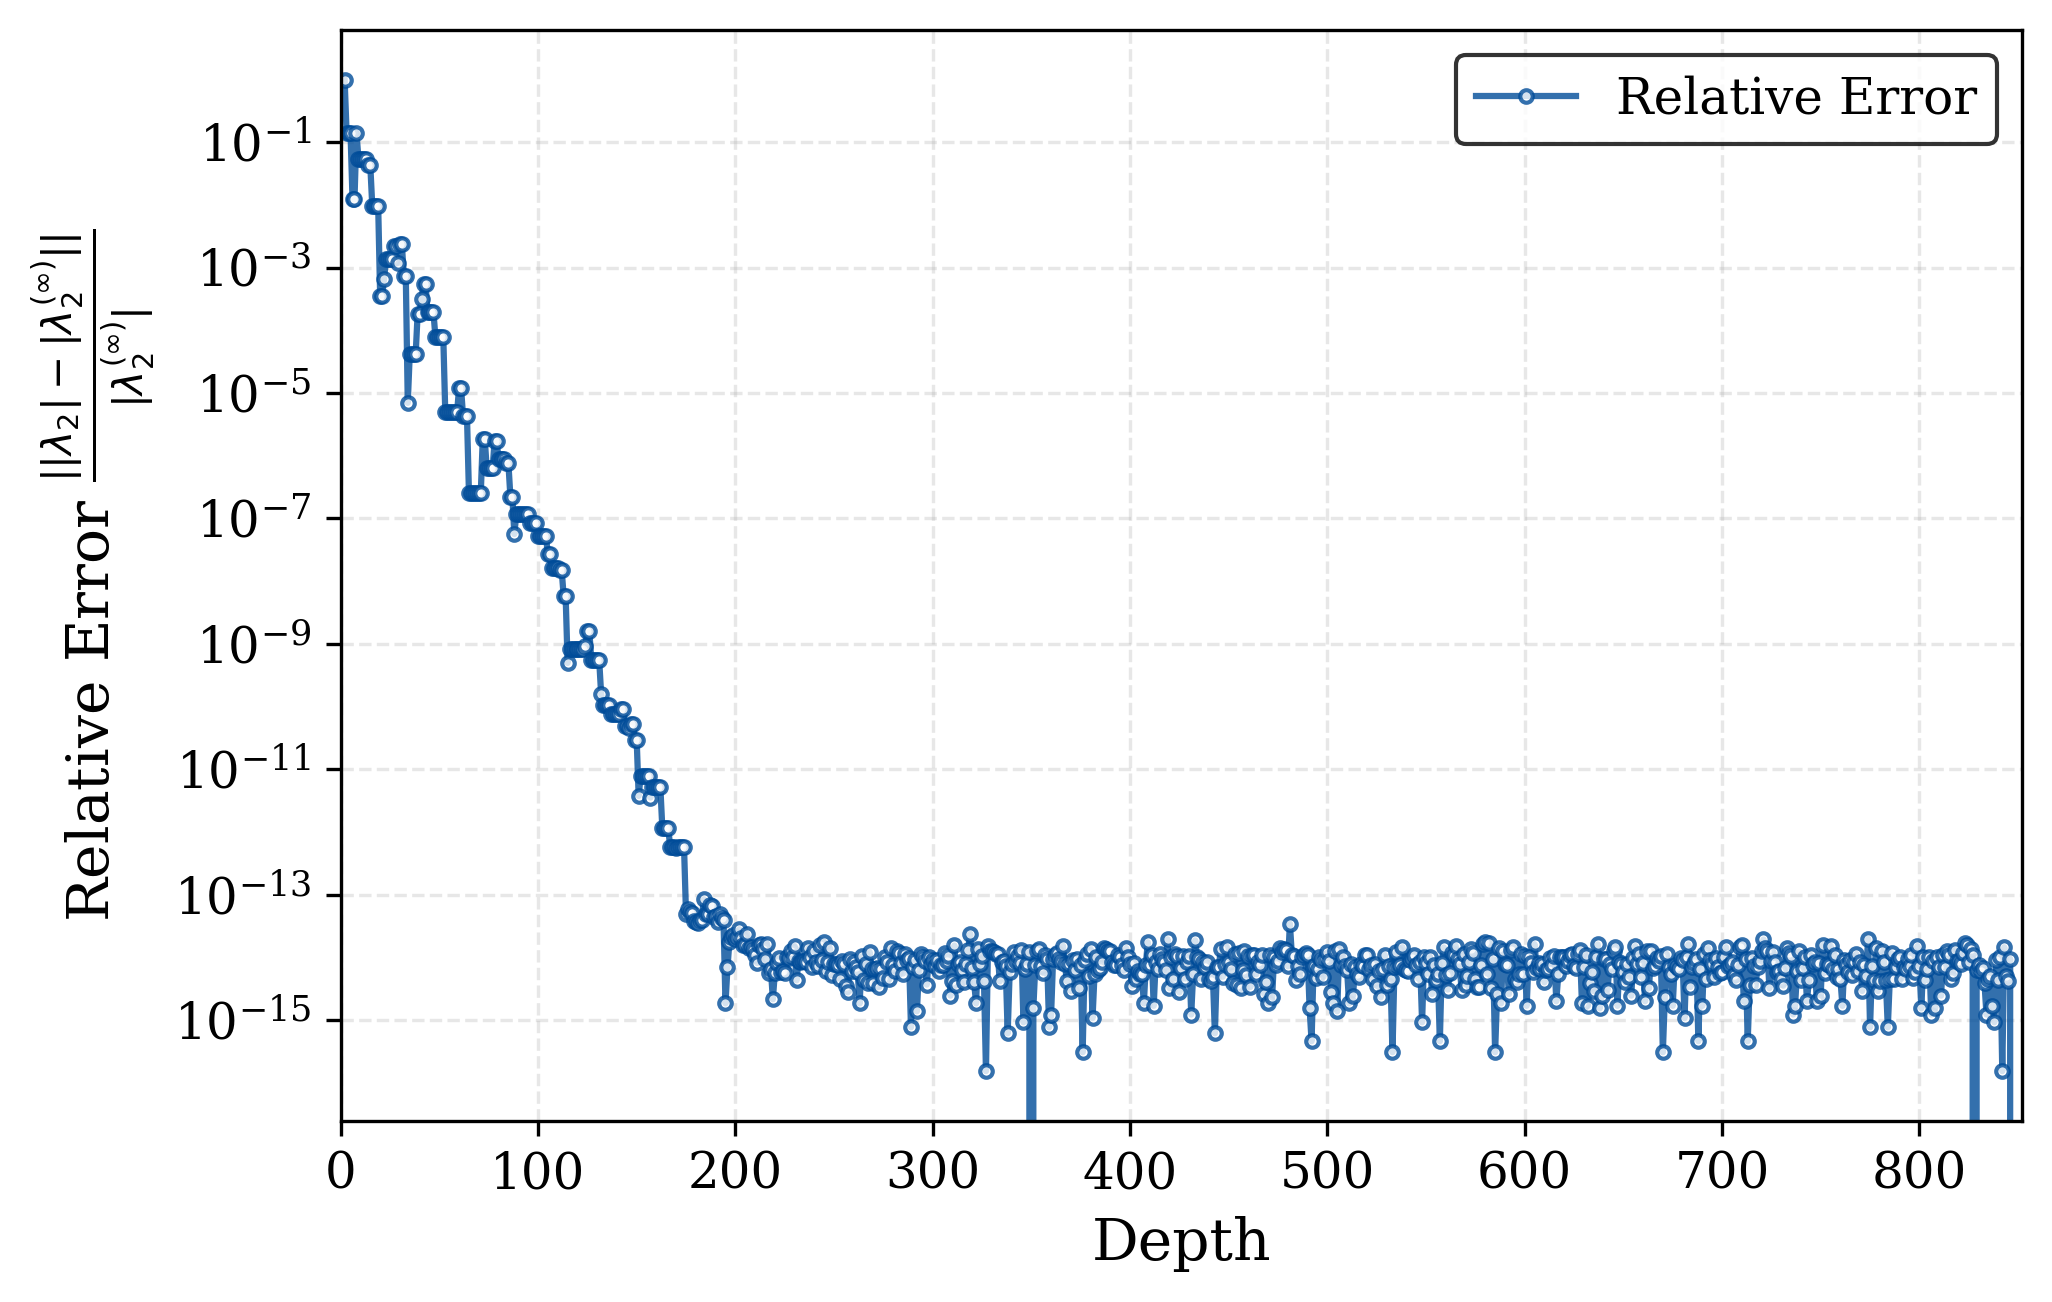

In [ ]:
error = np.abs(np.abs(l2) - np.abs(l2[-1])) / np.abs(l2[-1])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(depths, error, color='#004c99', linestyle='-', linewidth=1.5,
        marker='o', markersize=3, markerfacecolor='white', markeredgewidth=1,
        alpha=0.8, label=r'Relative Error')

ax.set_yscale('log')
ax.set_xlabel('Depth')

ax.set_ylabel(r'Relative Error $\frac{ | |\lambda_2| - |\lambda_2^{(\infty)}| | }{ |\lambda_2^{(\infty)}| }$')

ax.set_xlim(0, max(depths) + 5) # Give a little breathing room on the right
ax.grid(True, which="both", ls="--", alpha=0.3) # Render minor tick grids for log scale
ax.legend(loc='upper right', frameon=True, edgecolor='black')

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('eigenvalue_convergence.pdf', format='pdf', bbox_inches='tight') # PDFs are lossless vectors, best for LaTeX
plt.show()

In [113]:
spec_mags_ulam = []
times_ulam = []

for N in range(5, 10_000, 100):
    M = N
    tic = time.time()
    ulam_res = ulam_spec(N, M, 2)
    toc = time.time()
    times_ulam.append(toc - tic)
    spec_mags_ulam.append(ulam_res[0])

spec_mags_ulam = np.array(spec_mags_ulam)

In [150]:
max(times_ulam)

147.90352630615234

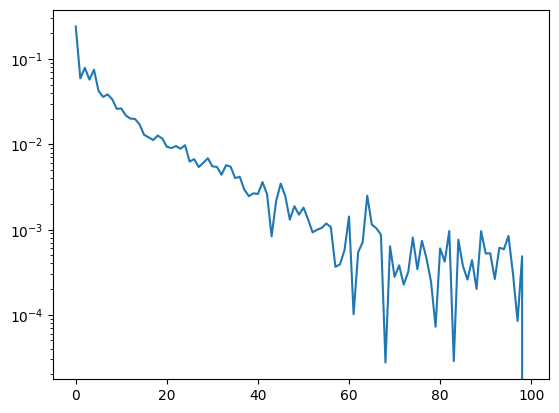

In [145]:
plt.plot(np.abs(spec_mags_ulam[:, 1] - spec_mags_ulam[-1, 1]))
plt.yscale('log')
plt.show()

In [ ]:
import pandas as pd

In [117]:
pd.DataFrame({'time': times_ulam, 'l2_mag': spec_mags_ulam[:, 1]}).to_csv('t',index=False)

In [158]:
from pathlib import Path

In [172]:
df = pd.read_csv('../../../results/tent_map/l2_vs_alpha.csv', index_col=0)

In [182]:
l2_abs_v_alpha = np.abs(df['lam_2'].str.strip('()').str.replace(' ', '').astype(complex))
alphas = l2_abs_v_alpha.index

/tmp/ipykernel_27776/1337862166.py:47: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  mark, lines = ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.5, linewidth=1.2)


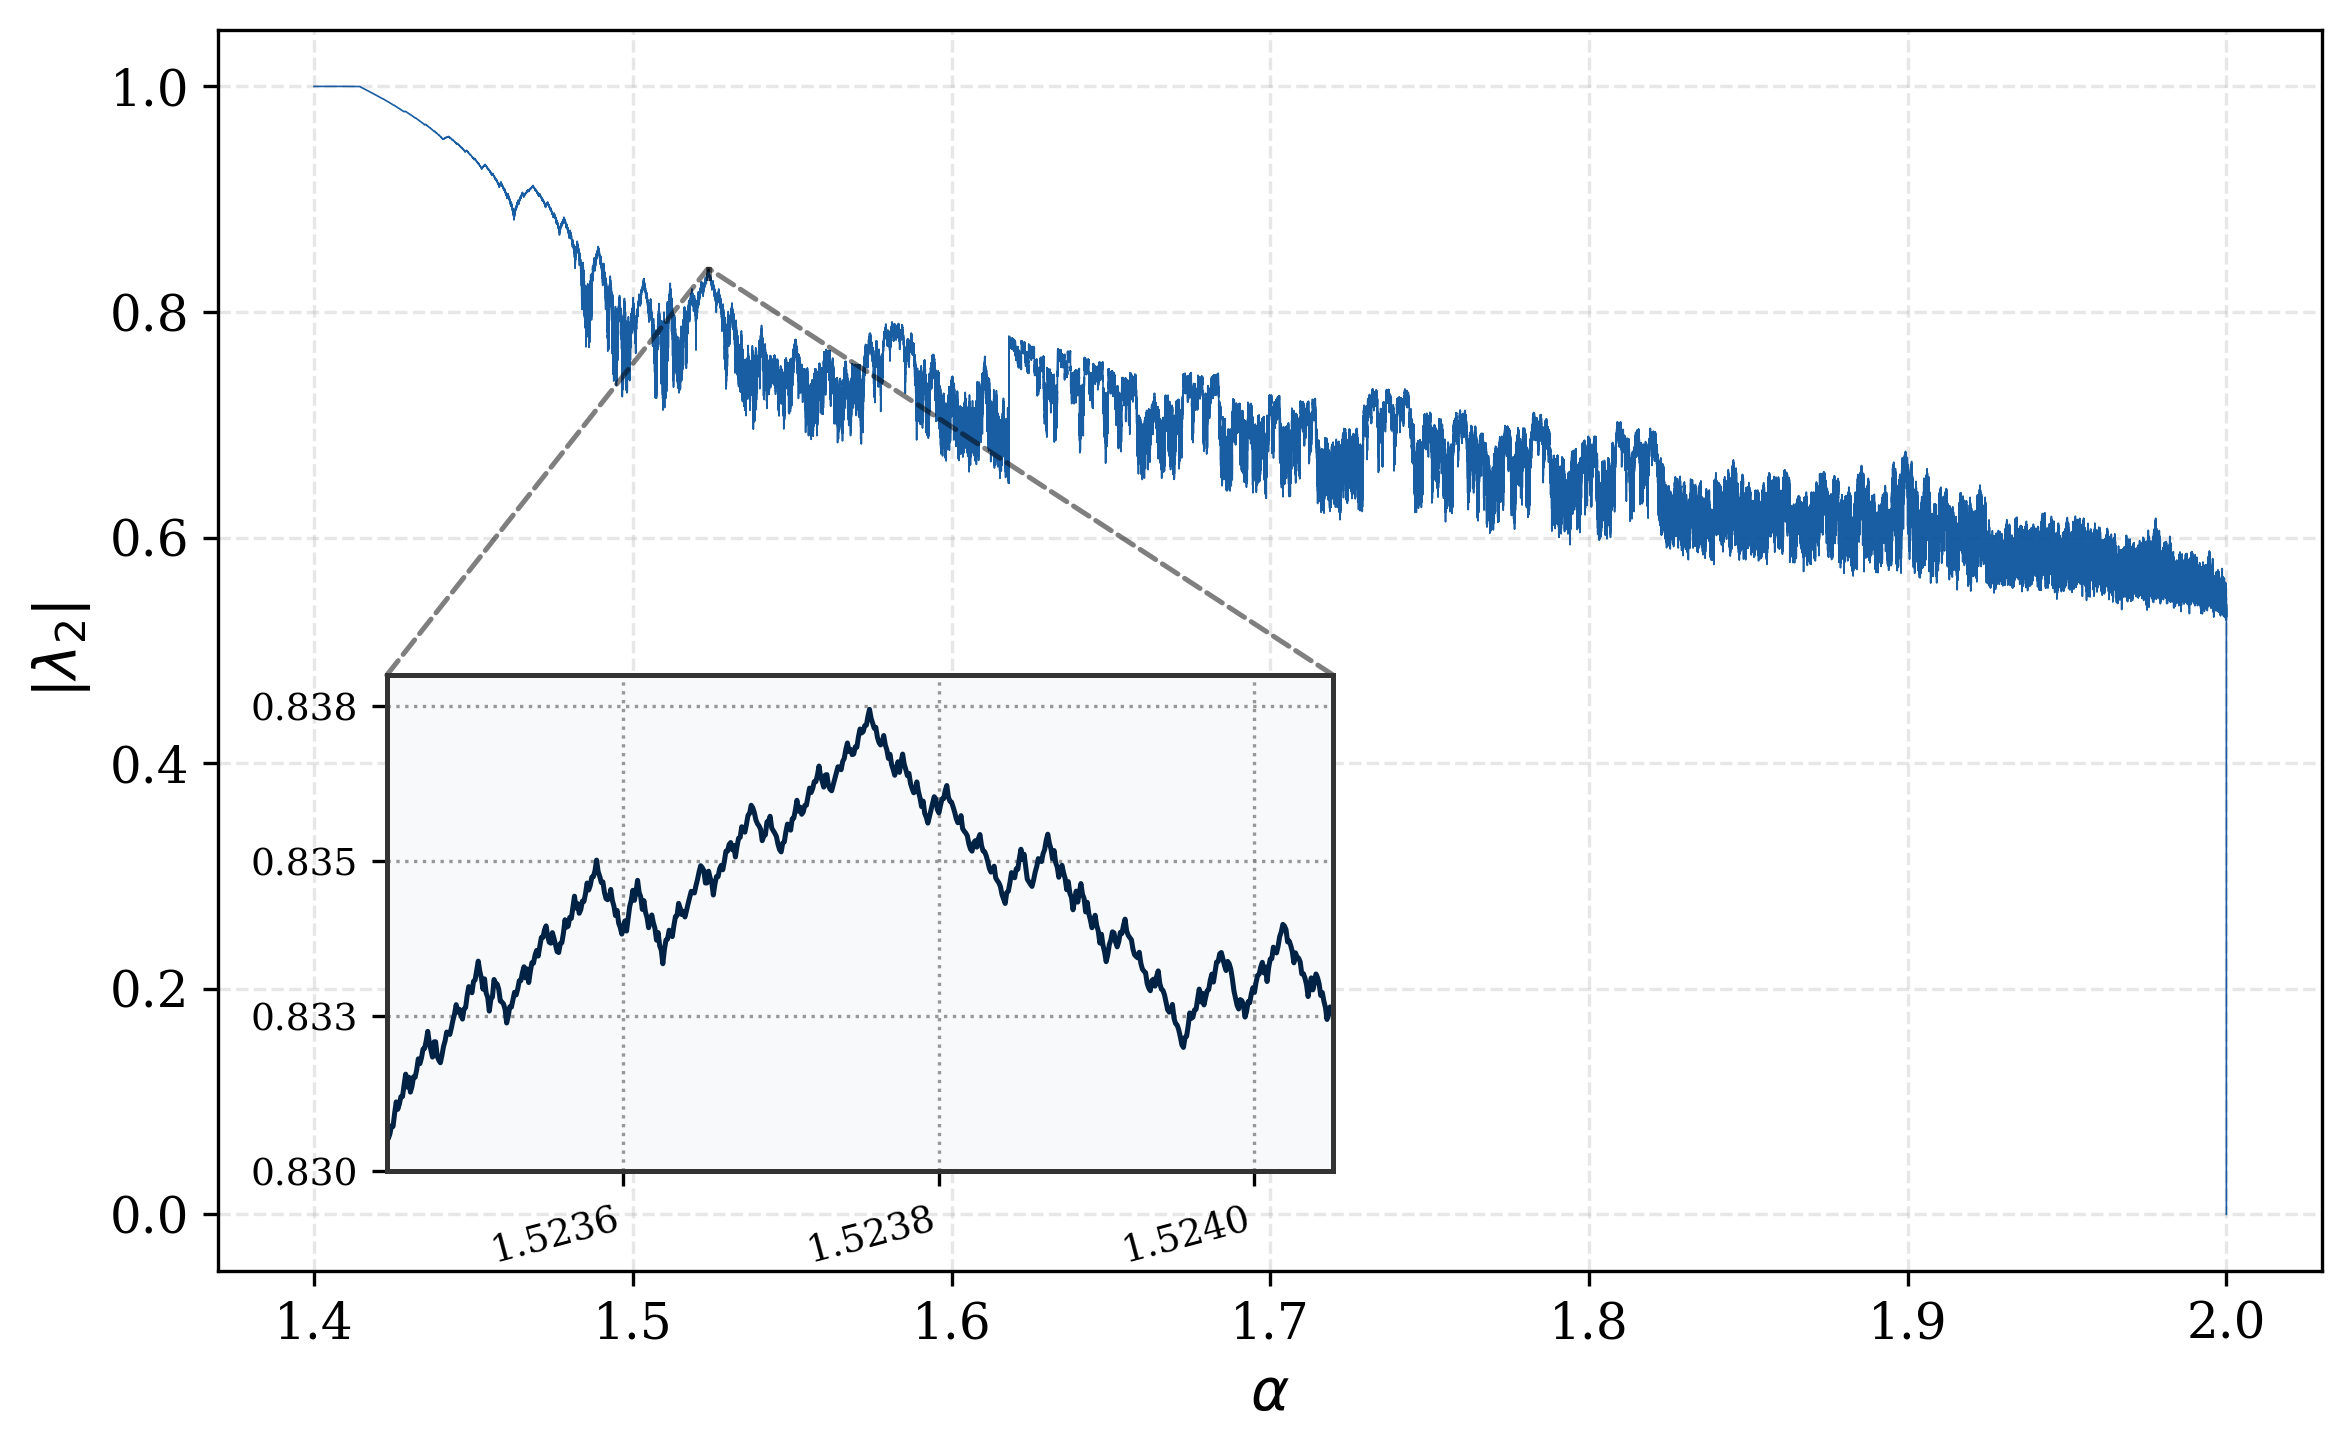

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# --- Main Plot ---
ax.plot(alphas, l2_abs_v_alpha, color='#004c99', linewidth=0.4, alpha=0.9)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$|\lambda_2|$')

# Main plot grid (subtle)
ax.grid(True, linestyle='--', alpha=0.3)

# --- Inset Plot (The Zoom) ---
axins = ax.inset_axes([0.08, 0.08, 0.45, 0.4])

axins.plot(alphas, l2_abs_v_alpha, color='#002244', linewidth=1.2)

# Your tight Zoom Coordinates
x1, x2 = 1.52375 - 0.0003, 1.52375 + 0.0003
y1, y2 = 0.83, 0.838

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# --- Prettifying the Inset ---
axins.set_facecolor('#f8f9fa')

# 1. Spacing: Limit the number of ticks
axins.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
axins.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# 2. THE FIX: Force strict decimal formatting
# (4 decimals for X to handle the 0.0003 spread, 3 decimals for Y)
axins.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
axins.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

# 3. THE FIX: Shrink the font slightly and rotate the X-axis labels
# so they don't crash into each other horizontally
plt.setp(axins.get_xticklabels(), rotation=15, ha='right', fontsize=9)
plt.setp(axins.get_yticklabels(), fontsize=9)

# 4. Grid and borders
axins.grid(True, linestyle=':', alpha=0.8, color='gray')
for spine in axins.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('#333333')

# --- Connect the Main Plot to the Inset ---
mark, lines = ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.5, linewidth=1.2)
for line in lines:
    line.set_linestyle('--')

plt.tight_layout()
plt.savefig('tent_map_abs_l2_v_alpha.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [10]:
import pandas as pd

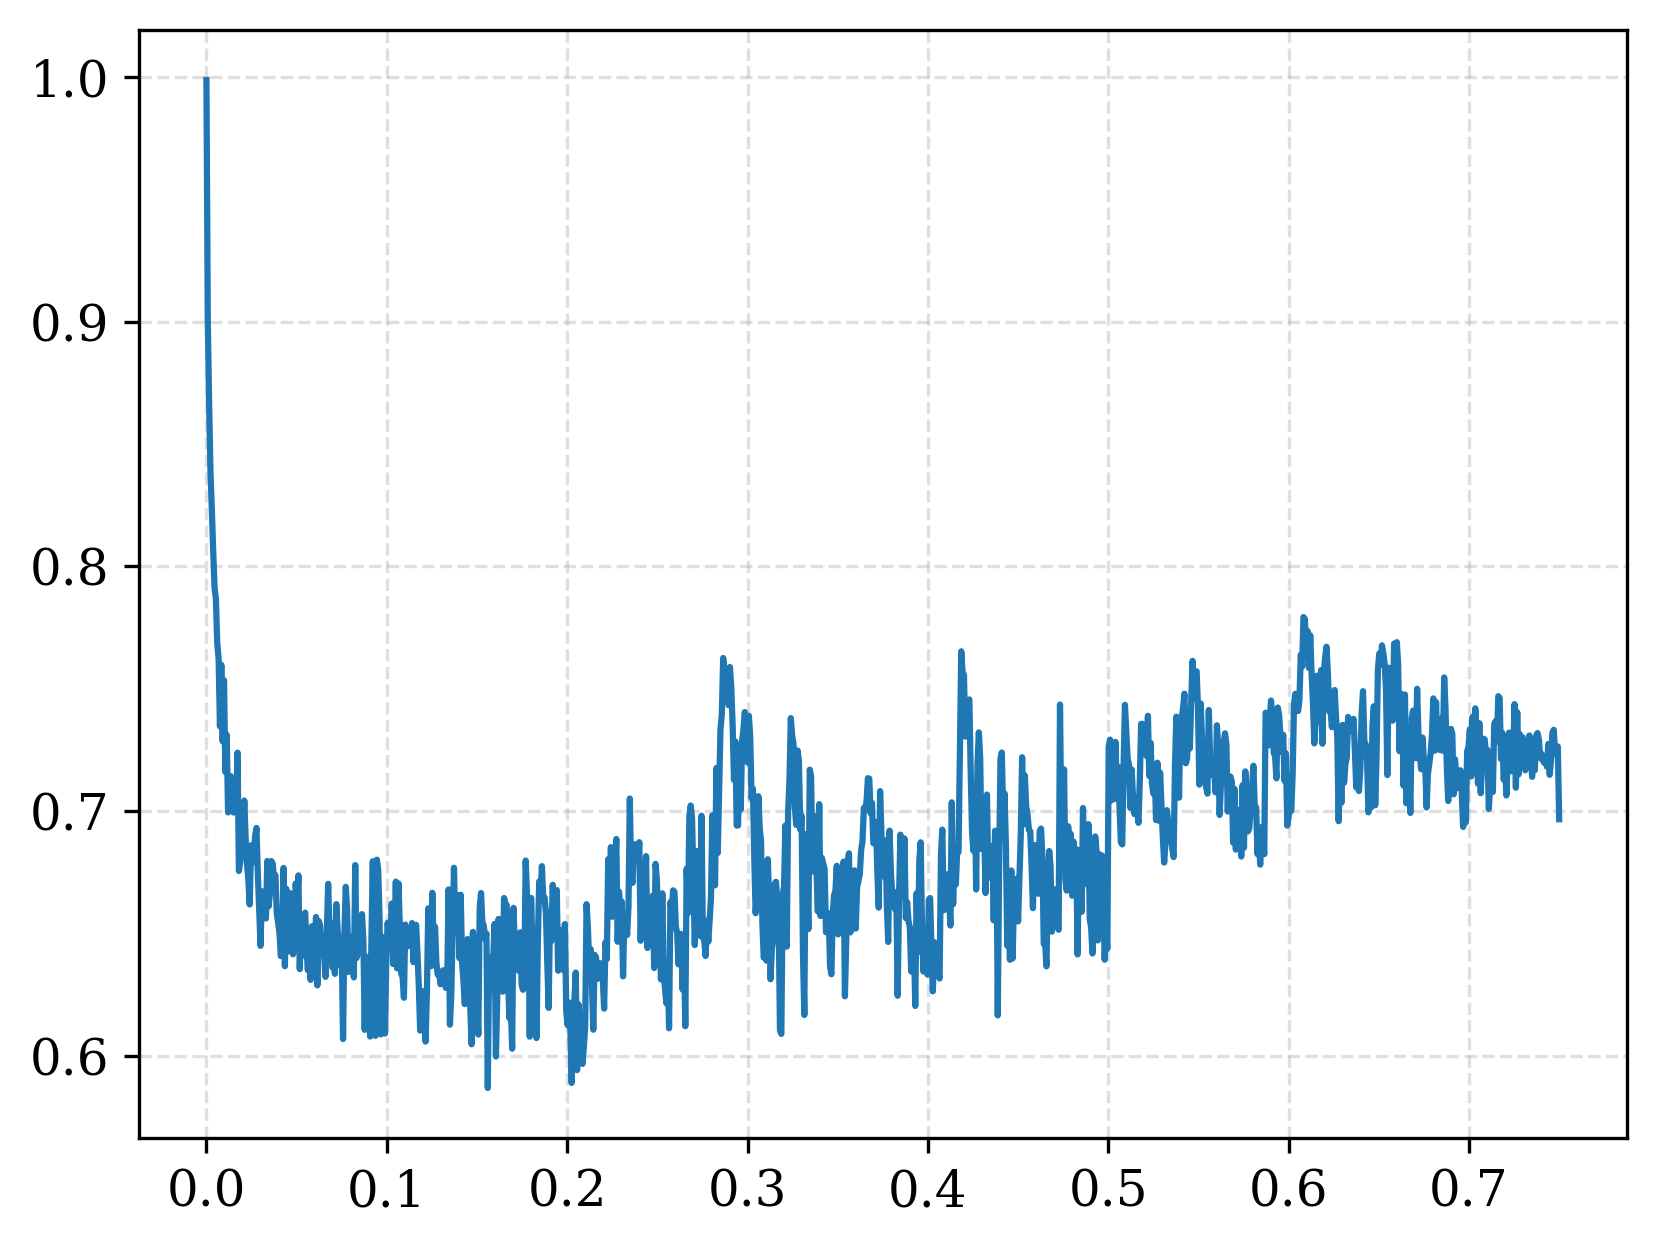

In [20]:
l2_attractor = pd.read_csv("../../../res.csv", index_col=0).squeeze()
assert isinstance(l2_attractor, pd.Series)

plt.plot(l2_attractor)